# Aim 3
Tara Cornwell June 2024

Adapted from Darici and Kuo

In [1]:
# Import necessary packages
using DynLoco_TC, Plots, CSV, DataFrames, Statistics, StructArrays

# Constants
g = 9.81
L = 1
norm_t = (L/g)^0.5
norm_v = (g*L)^0.5
nsteps = 5

# Clear variables
wstar = nothing

# Nominal gait
wstar = findgait(WalkRW2lvs(safety=true), target=:speed=>0.32, varying=:P);
nom_u = optwalk_TC(wstar, nsteps, boundaryvels = (wstar.vm, wstar.vm), boundarywork=false, J="u");

# Perturbed gait
#p_u = optwalk_TC(wstar, nsteps, boundaryvels = (wstar.vm, wstar.vm), boundarywork=false, J="u", perts = [1 1 1.5 1 1]);


In [ ]:
using MAT
matwrite("nominal_u.mat", Dict("nominal_u" => nom_u))

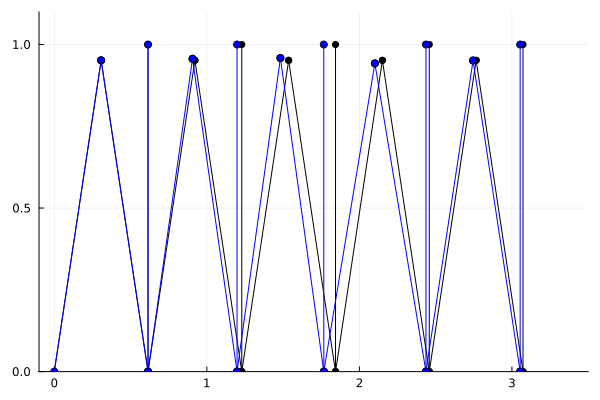

In [261]:
# Function for simple plots

function plot_walker(w, solution, nsteps, color)
    # x = distance, y = height of com at MS
    sls = solution.steps.steplength
    x = cumsum(sls)
    y = w.L.*ones(nsteps,1);

    list(a) = Any[i for i ∈ a]
    angles = list(solution.steps.θnew)

    # x and y at HS
    y_hs = list([L*cos(angles[1]); L*cos(angles[2]); L*cos(angles[3]); L*cos(angles[4]); L*cos(angles[5])])
    x_hs = list([x[1]-sls[1]/2; x[2]-sls[2]/2; x[3]-sls[3]/2; x[4]-sls[4]/2; x[5]-sls[5]/2])
    
    # Locations of feet
    xx = Matrix([x_hs'; x']')
    yy = Matrix([y_hs'; zeros(1,nsteps)]')

    x_temp = [0, x[1], x[2], x[3], x[4]]
    xxx = Matrix([x_temp'; x_hs']')
    yyy = Matrix([zeros(1,nsteps); y_hs']')
    

    for i in 1:nsteps
        # Phase 1
        plot!(p1, xxx[i,:], yyy[i,:], linecolor = color, markershape = :circle, markercolor = color)

        # Phase 2
        plot!(p1, xx[i,:], yy[i,:], linecolor = color, markershape = :circle, markercolor = color)

        # Phase 3
        plot!(p1, [x[i], x[i]], [0, y[i]], linecolor = color, markershape = :circle, markercolor = color, legend = :none)
    end

end

# Set up plot
p1 = plot(xlims = (-0.1, 3.5), ylims = (0, 1.1), xticks = 0:1:10, yticks = 0:0.5:1)

plot_walker(wstar, nom_u, nsteps, "black")
plot_walker(wstar, p_u, nsteps, "blue")

plot(p1)

In [3]:
perts = [1 1 1.5 1 1]
J = "u"

# Apply naive control to perturbation condition
naive = multistep(wstar, Ps=nom_u.steps.P, perts=perts)

# No anticipatory control - just react after the perturbation happens
reactive_1 = multistep(wstar, Ps=nom_u.steps.P[1:3], perts = [1 1 1.5])
reactive_2 = optwalk_TC(wstar, nsteps-3, boundaryvels=(reactive_1.steps[end].vm,wstar.vm), boundarywork=false, perts=[1 1], J=J)
reactive_u = cat(reactive_1, reactive_2);

In [5]:
using MAT
matwrite("naive.mat", Dict("naive" => naive))

LoadError: This is the write function for CompositeKind, but the input doesn't fit

In [6]:
using MAT
matwrite("reactive_u.mat", Dict("reactive_u" => reactive_u))

LoadError: This is the write function for CompositeKind, but the input doesn't fit

In [243]:
# Animate
p1 = plot(xlims = (-0.1, 3.5), ylims = (0, 1.1), xticks = 0:1:10, yticks = 0:0.5:1)

anim = @animate for i ∈ 1:nsteps
    # COM & foot positions
    for phase in 1:3
        if phase == 1
            xp = xxx[i,:]
            yp = yyy[i,:]
        elseif phase == 2
            xp = xx[i,:]
            yp = yy[i,:]
        elseif phase == 3
            xp = [x[i], x[i]]
            yp = [0, y[i]]
        end
        plot!(p1, xp, yp, linecolor = :black, markershape = :circle, markercolor = :black, legend = :none)
        plot(p1)
    end
    # Phase 1
    #plot!(p1, xxx[i,:], yyy[i,:], linecolor = :black, markershape = :circle, markercolor = :black)
    #plot(p1)
    
    # Phase 2
    #plot!(p1, xx[i,:], yy[i,:], linecolor = :black, markershape = :circle, markercolor = :black)
    #plot(p1)
    
    # Phase 3
    #plot!(p1, [x[i], x[i]], [0, y[i]], linecolor = :black, markershape = :circle, markercolor = :black, legend = :none)
    #plot(p1)
end
#gif(anim, "anim_fps1.gif", fps = 1)

Animation("/var/folders/7k/r8_pmwmd6h36mnnn44mnf52c0000gn/T/jl_dWpncd", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png"])